In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

2025-04-02 14:45:42.335298: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.85. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana2/snert/max/data/amigo_files/"
    data_path = "/media/morgana2/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana2/snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana2/snert/max/data/amigo_files/"
    data_path = "/Users/mcha5804/JWST/WR137/calslope/"
    uncal_path = "/Users/mcha5804/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/wr137/")

state = np.load(
    os.path.join(model_cache, "conv_up_model.npy"), allow_pickle=True
).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
def truncate_files(files, ngroups):
    """
    Truncate the ramp of files to only have ngroups.
    """
    # TODO do one_on_fs here

    for file in files:

        top_group = file["RAMP"].data.shape[0]
        up_to = top_group - ngroups

        # files are mutable, so they will change in place
        for attr in ["RAMP", "SLOPE", "RAMP_ERR", "RAMP_SUP", "SLOPE_SUP"]:
            file[attr].data = file[attr].data[:-up_to, ...]

        file["SLOPE_ERR"].data = file["SLOPE_ERR"].data[:-up_to, :-up_to, ...]

In [4]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    # if file[0].header["TARGPROP"] == "NGC1068":
    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 2236"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

# dorito.misc.truncate_files(cal_files, 5)
# dorito.misc.truncate_files(sci_files, 18)
# truncate_files(sci_files, 18)

In [5]:
import jax.random as jr
from amigo.rnn_models import PixelNonLinearity, ConvRNN, RNNRamp

ramp_model = ConvRNN(key=jr.key(0), use_bias=False, bias_value=1e-3)
ramp_model = RNNRamp(ramp_model, gain_model=PixelNonLinearity())

In [6]:
import zodiax as zdx
import jax
from jax import numpy as np, tree as jtu, Array
import jaxwt


class Wavelets(zdx.WrapperHolder):
    level: int
    wavelet: str
    approx: Array

    def __init__(
        self,
        distribution,
        level=2,
        wavelet="db2",
    ):

        # Overriden later, just to avoid recursion error
        self.structure = None

        # setting the wavelet parameters
        self.level = level
        self.wavelet = wavelet

        # converting to wavelet coefficients
        distribution = distribution / distribution.sum()
        approx, detail_tree = self.wavelet_transform(distribution)
        self.approx = approx

        # storing the details in a EquinoxWrapper
        details, structure = zdx.build_wrapper(detail_tree)
        self.values = details
        self.structure = structure

    @property
    def distribution(self) -> Array:
        """
        Returns the normalised intensity distribution of the source.
        """

        # reconstructing the distribution
        return jaxwt.waverec2(self.coeffs, self.wavelet)[0]

    def wavelet_transform(self, array) -> Array:
        # converting to wavelet coefficients
        coeffs = jaxwt.conv_fwt_2d.wavedec2(
            array,
            self.wavelet,
            level=self.level,
        )
        approx = coeffs[0][0]
        detail_tree = coeffs[1:]

        return approx, detail_tree

    def normalise(self):
        """
        Normalises the wavelet coefficients such that the
        corresponding distribution sums to 1.
        """
        dist = self.distribution

        # clipping and normalising the distribution
        dist = np.clip(dist, 0)
        dist = dist / dist.sum()

        # converting to wavelet coefficients
        approx, detail_tree = self.wavelet_transform(dist)
        details = self.flatten_details(detail_tree)

        return self.set(["approx", "values"], [approx, details])

    @property
    def coeffs(self):
        """
        Returns the wavelet coefficients.
        """
        # building the detail tree from the values and structure
        detail_tree = self.build

        # converting to wavelet coefficients with approx
        return [self.approx[None, ...], *detail_tree]

    def flatten_details(self, detail_tree):
        """
        Flattens the wavelet coefficients.
        """
        # flattening the coefficients
        detail_leaves, _ = jtu.flatten(detail_tree)
        return np.concatenate([val.flatten() for val in detail_leaves])

    def update_distribution(self, dist, normalise=True):
        """
        Updates the distribution of the wavelet coefficients.
        """

        # clipping and normalising the distribution
        if normalise:
            dist = np.clip(dist, 0)
            dist = dist / dist.sum()

        # converting to wavelet coefficients
        approx, detail_tree = self.wavelet_transform(dist)
        details = self.flatten_details(detail_tree)

        return self.set(["approx", "values"], [approx, details])


class WaveletModel(dorito.models.ResolvedAmigoModel):

    wavelets: None

    def __init__(
        self,
        params,
        optics,
        ramp,
        detector,
        read,
        filters,
        wavelets,
    ):
        self.wavelets = wavelets

        super().__init__(
            params=params,
            optics=optics,
            ramp=ramp,
            detector=detector,
            read=read,
            filters=filters,
        )


def L1_loss(arr):
    """
    L1 Norm loss function.
    """
    return np.nansum(np.abs(arr))


def L1_REG(model, exposure, args):
    # grabbing flux
    flux = 10 ** model.fluxes[exposure.get_key("fluxes")]

    # grabbing the distribution and scaling by flux
    distribution = exposure.get_distribution(model)
    source = flux * distribution

    # wavelet transforming
    wavelets = model.wavelets.update_distribution(source, normalise=False)

    # returning L1 on the details (#TODO NOT APPROX?)
    return L1_loss(wavelets.values)

In [7]:
source_size = 112
level = 5
# # shearlets, shearletSystem = dorito.build_model.shearlet_prior(source_size, nScales=2)
wavelets = Wavelets(np.ones((source_size, source_size)), level=level, wavelet="db2")

model, params, cal_fits, sci_fits = dorito.build_model.build_resolved_model(
    # model, params, cal_exposures, sci_exposures = dorito.build_model.build_resolved_model(
    cal_files,
    [],
    # sci_files[3:4],
    # cal_files,
    # sci_files[0:1],
    # [],
    state=state,
    # modeller=dorito.models.ResolvedAmigoModel,
    modeller=WaveletModel,
    wavelets=wavelets,
    ramp_model=ramp_model,
    extra_priors={
        # "approx": np.log10(wavelets.approx),
        # "details": wavelets.values,
        "log_distribution": np.log10(
            np.ones((source_size, source_size)) / source_size**2
        ),
        "spectral_coeffs": np.array([1.0, 0.0]),
    },
    sci_fit=dorito.model_fits.DynamicResolvedFit,
    # sci_fit=dorito.model_fits.ResolvedFit,
    Teff_cache=teff_cache,
    separate_fits=True,
)
fits = [*cal_fits, *sci_fits]

# init state
# init_state = np.load(init_state_cache + "F430M.npy", allow_pickle=True)[()]
# for p in [
#     "positions",
#     "fluxes",
#     "aberrations",
#     # "log_distribution",
# ]:
#     for key in init_state[p].keys():
#         params[p][key] = init_state[p][key]

#     # params[p] = init_state[p]
# model = model.set("params", params)

model = model.set("FF", np.load(os.path.join(model_cache, "FF.npy")))
model = model.set(
    "non_linearity", np.load(os.path.join(model_cache, "non_linearities.npy"))
)

In [24]:
# for exp in cal_fits:

#     top = np.where(~exp.badpix, exp.ramp[-1], np.nan)

#     plt.figure(figsize=(8, 2))
#     plt.subplot(131)
#     plt.imshow(top, cmap=inferno)
#     plt.colorbar()
#     plt.title("Top group")
#     plt.subplot(132)
#     plt.imshow(exp.slopes[-1], cmap=viridis)
#     plt.subplot(133)
#     plt.hist(top.flatten(), log=True)
#     plt.show()

In [32]:
sci_keys = []
for exp in fits:
    if not exp.calibrator:
        sci_keys.append(exp.map_param("positions"))


def kill_pos_grads(model, grads, args):
    grads = grads.multiply(sci_keys, 0.0)
    return grads, args


eps = 1e2


def term_looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.2f}")

    if len(list(loss_dict.values())[0]) > 10:
        last_loss = np.array([v[-2] for v in loss_dict.values()]).mean(0)
        if np.abs(last_loss - loss) < eps:
            return True

    return False

In [ ]:
n_epoch = 200

config = {
    # "positions": sgd(1e-2, 0),
    # "positions": sgd(2e-2, 0),
    # "fluxes": sgd(2e-1, 0),
    # "fluxes": sgd(2e-1, 20),
    # "aberrations": sgd(5e-2, 4),
    # "log_distribution": adam(7e-2, 0),  # , (10, 0.25), b1=0.7),
    # "log_distribution": adam(5e-2, 5),  # , (10, 0.25), b1=0.7),
    # "positions": sgd(2e-2, 5),
    # "fluxes": sgd(2e-2, 0),
    # "one_on_fs": sgd(1e2, 6),
    # "approx": adam(1e-5, 0),
    # "approx": adam(6e-3, 8),
    # "details": adam(6e-9, 15),
    # "approx": adam(2e-2, 8),
    # "details": adam(2e-8, 15),
    # "source_spectrum.coefficients": sgd(1e-1, 5),
}

reg_dict = {
    # "L1": 2.0e3,
    # "L1": 3.0e-1,
    # "L2": None,
    # "TV": None,
    # "QV": 1.0e6,
    # "QV": 1.0e-3,
    # "ME": 1.0e2,
    # "SF": 1e3,
}

args = {
    "reg_dict": reg_dict,
    # # "reg_func_dict": dorito.stats.reg_func_dict,
    "reg_func_dict": {
        "L1": L1_REG,
        # "L1": dorito.stats.L1_on_wavelets,
        # "L1": L1_on_wavelets,
        # "QV": dorito.stats.TSV,
        # "ME": dorito.stats.ME,
    },
    # "mask": mask,
}

trainer = amigo.fitting.Trainer(
    dorito.stats.regularised_loss_fn,
    norm_fn=dorito.stats.normalise_distribution,
    # grad_fn=kill_pos_grads,
    cache=fisher_cache,
    looper_fn=term_looper,
)

trainer = trainer.update_fishers(
    model.set("ramp.bleed", False),
    # model,
    fits,
    args=args,
    verbose=True,
    parameters=[
        "positions",
        "fluxes",
        "aberrations",
        # "one_on_fs",
        # "log_distribution",
        # "spectral_coeffs",
    ],
)

# Train the model
result = trainer.train(
    model=model,
    # model=model.set("ramp.values", np.zeros_like(model.ramp.values)),
    optimisers=config,
    epochs=n_epoch,
    batches=fits,
    args=args,
)

# balance = dorito.stats.prior_data_balance(final_model, fits[-1], args)
# print(f"Likelihood: {balance[0]:.3e}, Prior: {balance[1]:.3e}")

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 324,160,915.05
Estimated run time: 0:00:18
Converged on epoch 194, exiting loop
Full Time: 0:00:27
Final Loss: 581,175.02


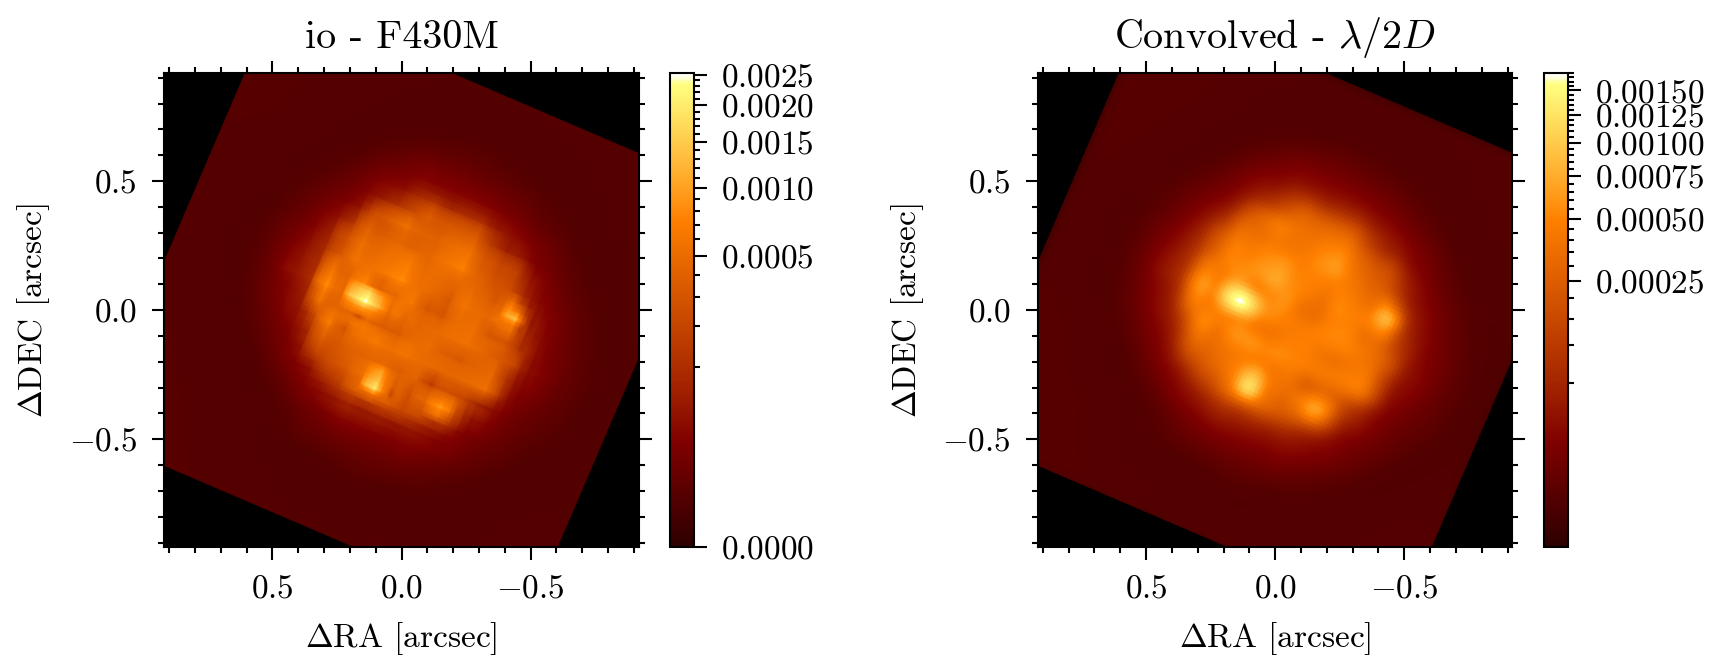

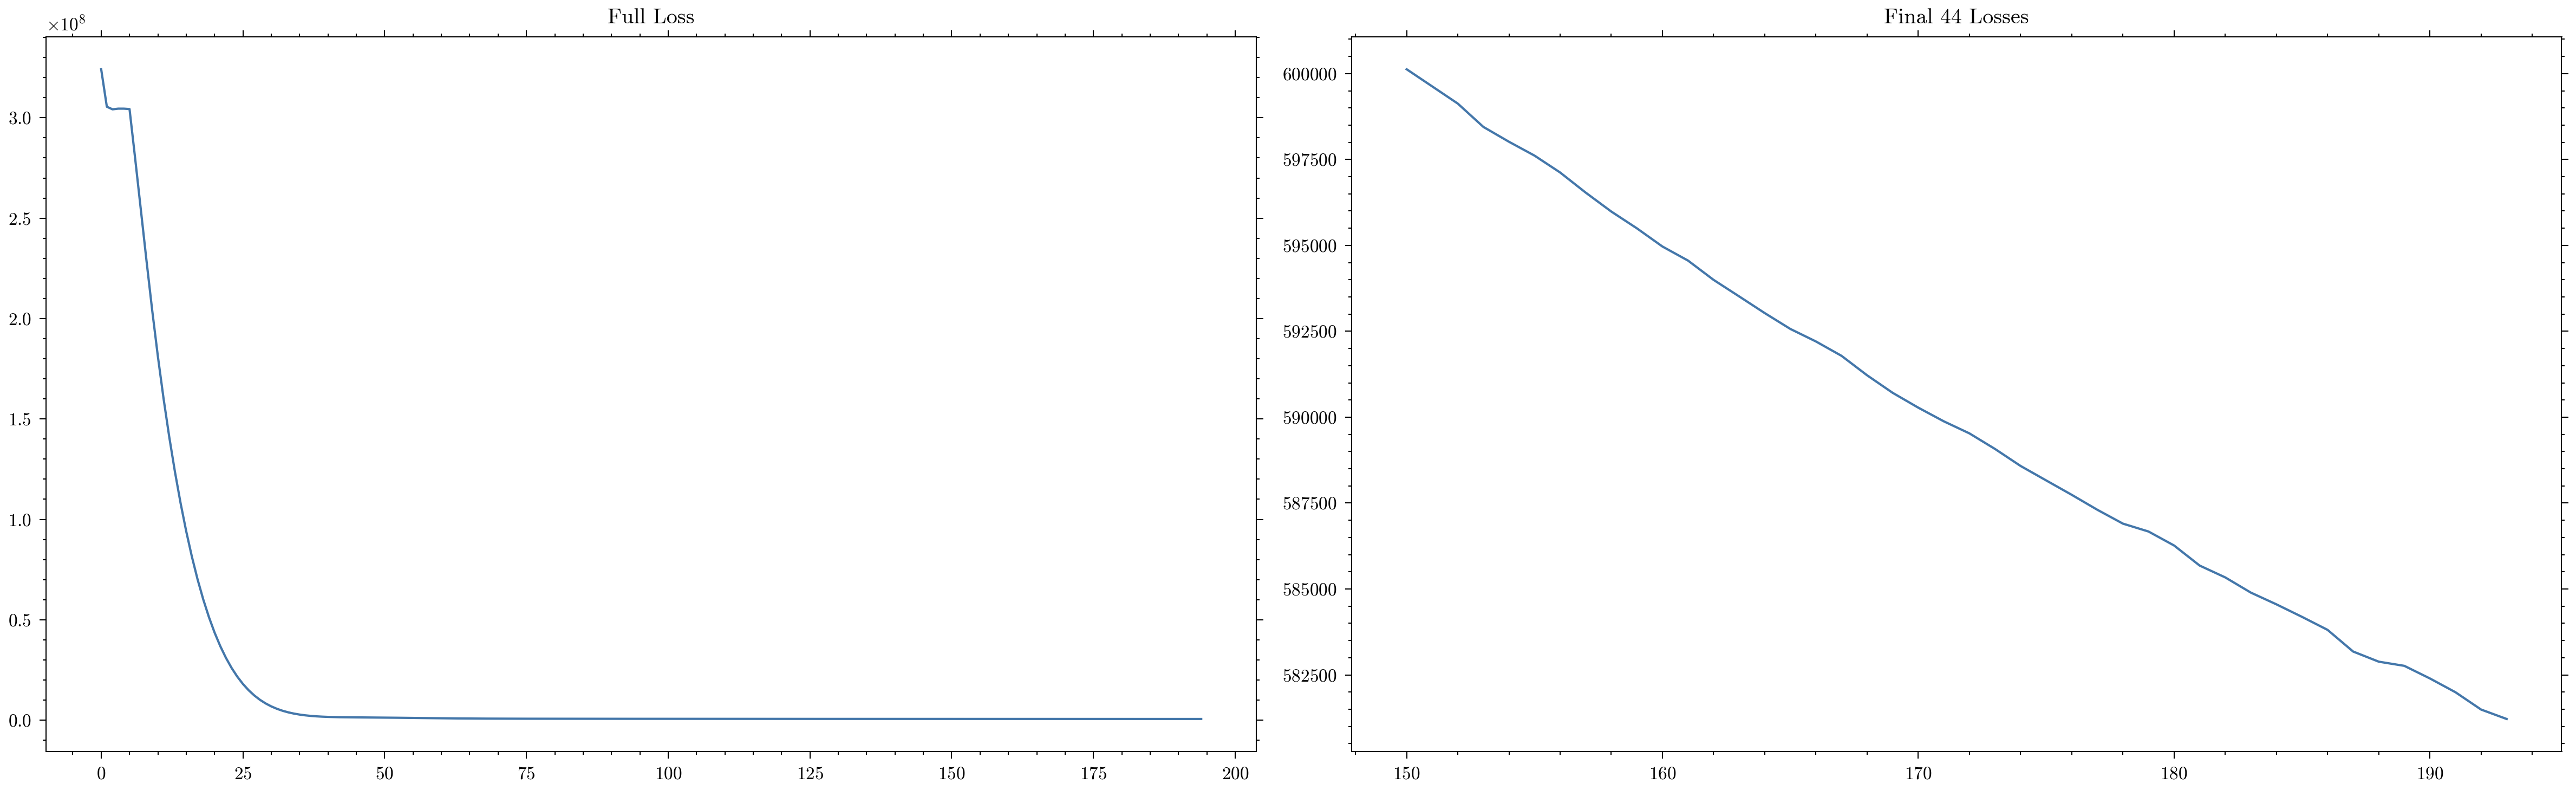

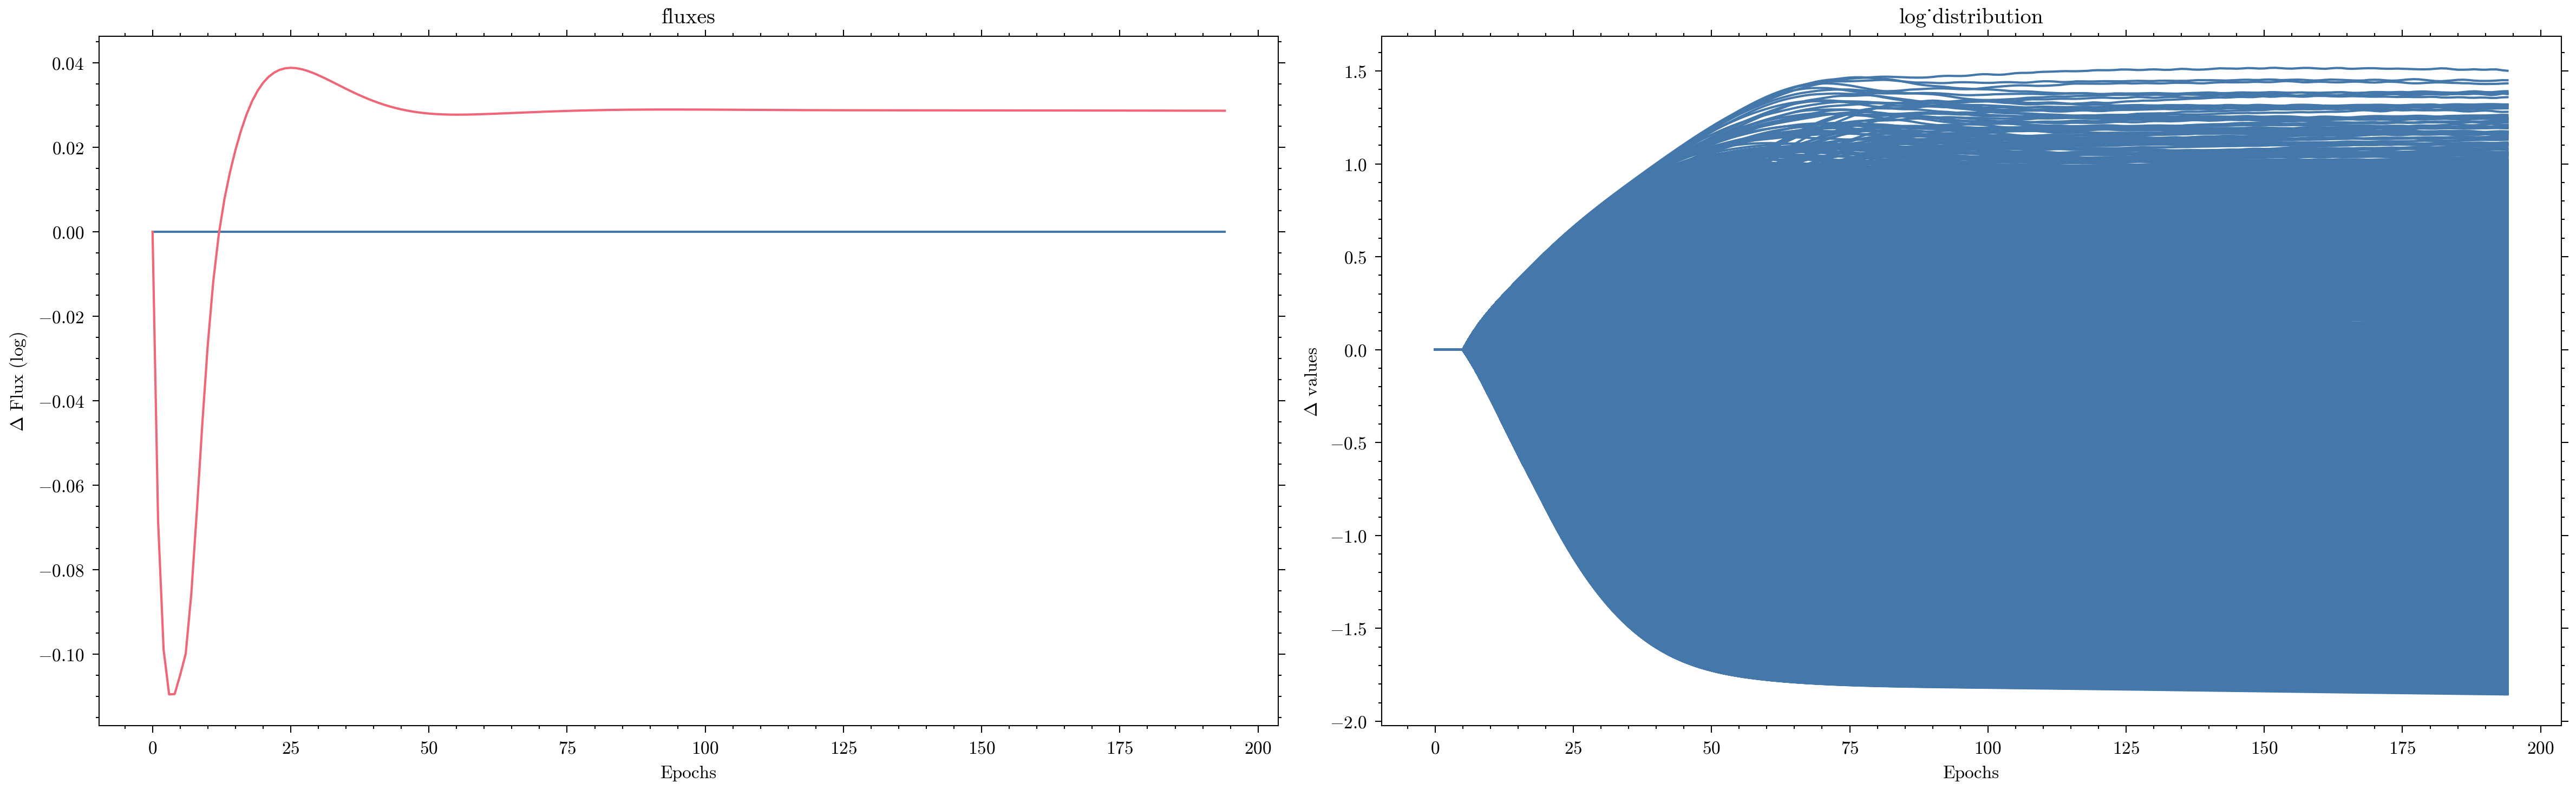

File 01373_017_02_04_1
Star IO
Filter F430M
nints 100
ngroups 18



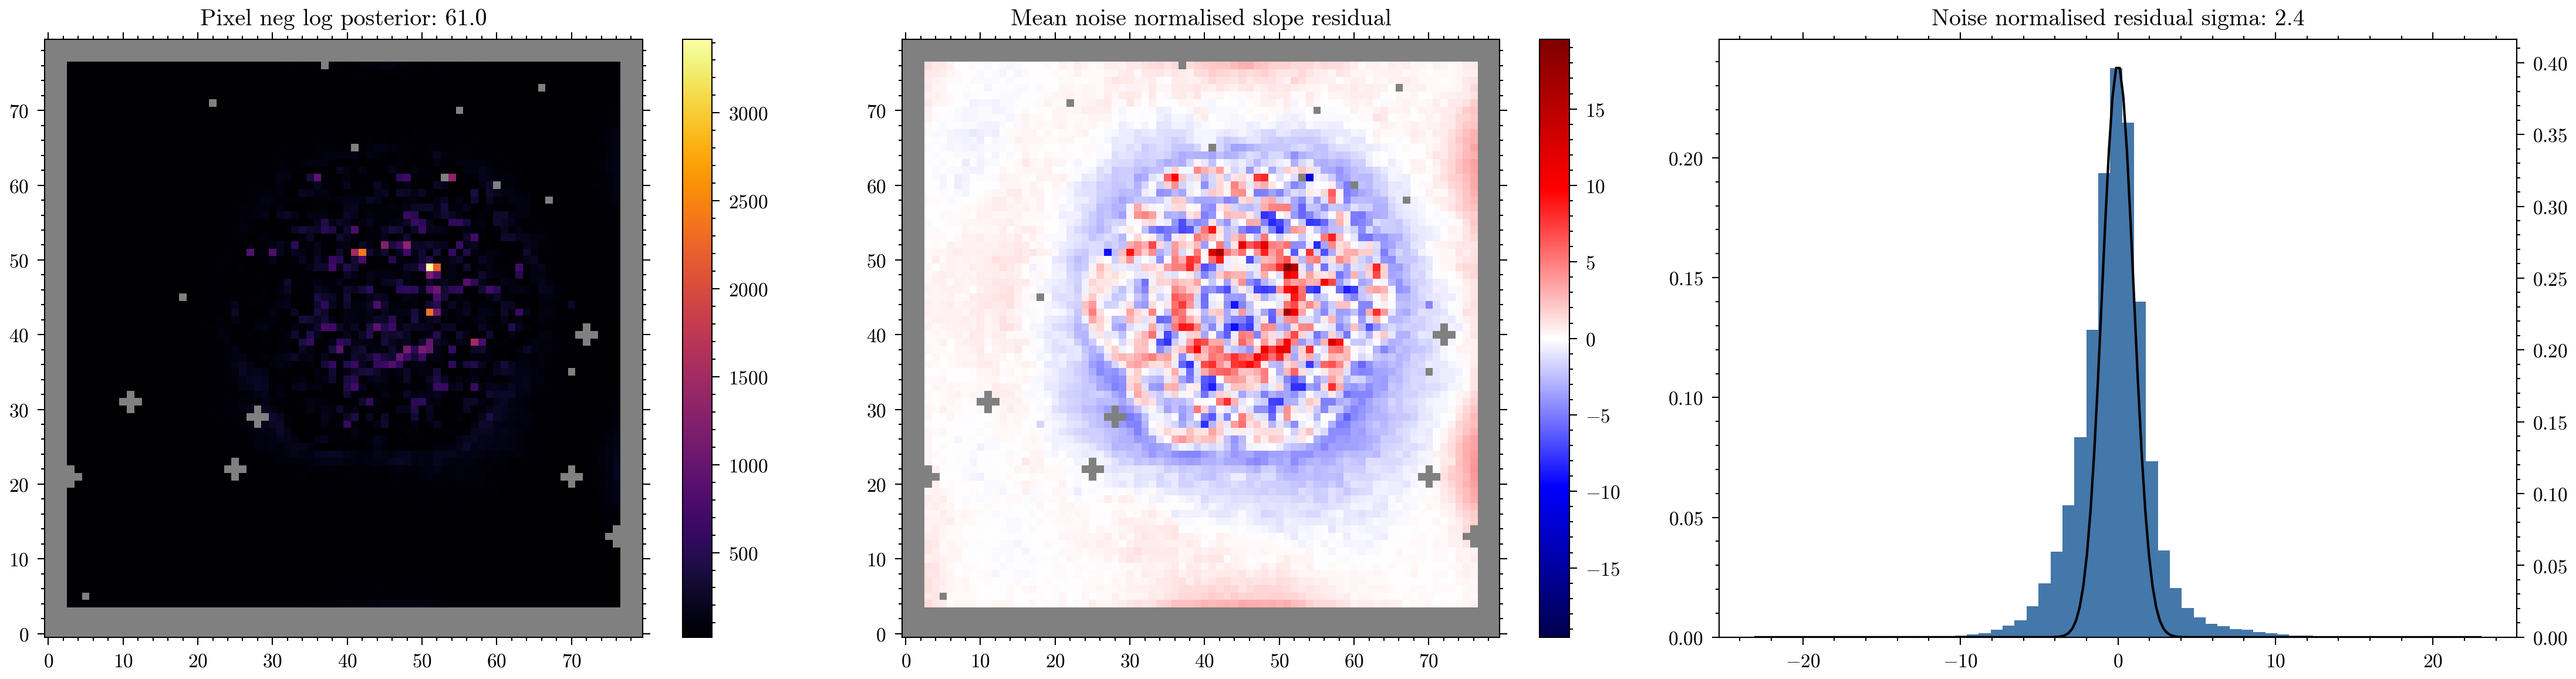

In [34]:
# np.save(init_state_cache + "F430M.npy", result.model.params)

flag = False
for exp in fits:

    try:
        if not flag:
            try:
                dist = result.model.get_distribution(exp)
            except:
                dist = exp.get_distribution(result.model)

            fig, ax = plt.subplots(1, 2, figsize=(6, 2.3))

            c0 = dorito.plotting.plot_result(
                ax[0],
                dist,
                roll_angle_degrees=-rolls[exp.filename],
                cmap="afmhot_10u",
                power=0.3,
                # model=final_model,
                vmin=0,
                # show_diff_lim=True,
                # vmax=io_peak_flux,
            )

            c1 = dorito.plotting.plot_result(
                ax[1],
                dorito.misc.blur_distribution(dist, result.model, exp, factor=0.5),
                cmap="afmhot_10u",
                power=0.3,
                vmin=None,
                roll_angle_degrees=-rolls[exp.filename],
                # model=hdb_final_model,
            )
            fig.colorbar(c1, ax=ax[1])

            fig.colorbar(c0)
            ax[0].set_title(f"io - {exp.filter}")
            ax[1].set(title=r"Convolved - $\lambda / 2D$")

            plt.tight_layout()
            # plt.savefig(output_path + f"{time}.png", dpi=300)
            # plt.close()
            plt.show()
        # flag = True
    except:
        continue

amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)

for exp in fits:
    exp.print_summary()
    amigo.plotting.summarise_fit(
        result.model,
        exp,
        # test_model,
    )

In [37]:
wavelets = result.model.wavelets.update_distribution(
    result.model.get_distribution(sci_fits[0]), normalise=False
)
dorito.plotting.tree_plot(wavelets.coeffs)

In [35]:
import planetmapper
import scipy

features = {
    "seth": (----131.67, -5.35),  # long [deg], lat [deg]
    # "P197": (None, None),
    "masubi": (----56.18, -49.6),
    "leizi": (----46.16, 14.25),
    "amirani": (----114.68, 24.46),
    # "subobs": (--107.57361768, 2.60587485),
}


def plot_io_with_ephemeris(
    ax,
    array,
    exp,
    data_dir,
    pixel_scale,
    roll_angle_degrees=0.00,
    legend=False,
    points=None,
    **kwargs
):

    body = planetmapper.Observation(data_dir + exp.filename[:-5] + "_nis_uncal.fits")
    if points is not None:
        body.coordinates_of_interest_lonlat = points

    def coordinate_func(ra, dec):
        x, y = body.radec2angular(ra, dec)
        return -x, y

    body.plot_wireframe_custom(
        # body.plot_wireframe_angular(
        ax,
        coordinate_func=coordinate_func,
        # aspect_adjustable="box",
        add_title=False,
        label_poles=True,
        indicate_equator=True,
        indicate_prime_meridian=True,
        grid_interval=30,
        grid_lat_limit=75,
        formatting={
            # "limb": {
            #     "linestyle": "--",
            #     "linewidth": 0.8,
            #     "alpha": 0.8,
            #     "color": "white",
            # },
            "grid": {
                "linestyle": "--",
                "linewidth": 0.5,
                "alpha": 0.3,
                "color": "k",
            },
            "equator": {"linewidth": 1, "color": "r", "label": "equator"},
            "terminator": {
                "linewidth": 1,
                "linestyle": "-",
                "color": "aqua",
                "alpha": 0.0,
                "label": "terminator",
            },
            "coordinate_of_interest_lonlat": {
                "color": "gold",
                "marker": "^",
                "facecolors": "none",
                # "markeredgecolor": "red",
                "s": 10,
                "label": "volcano",
            },
            "limb_illuminated": {"color": "b", "alpha": 0.0},
        },
    )

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper left",
        )

    im = plot_result(
        ax,
        array,
        pixel_scale=pixel_scale,
        roll_angle_degrees=roll_angle_degrees,
        show_diff_lim=True,
        **kwargs,
    )

    return im


def plot_result(
    ax,
    array,
    pixel_scale,
    roll_angle_degrees: float = 0.0,
    model=None,
    show_diff_lim: bool = True,
    cmap: str = "afmhot_10u",
    bg_color: str = "k",
    axis_labels: dict = {
        "xlabel": r"$\Delta$RA [arcsec]",
        "ylabel": r"$\Delta$DEC [arcsec]",
    },
    vmin: float = 0.0,
    vmax: float = None,
    power=0.5,
    contour=False,
    scale=1.0,
    translate=(0.0, 0.0),
):
    rotation_transform = (
        mpl.transforms.Affine2D()
        .translate(*translate)
        .rotate_deg(roll_angle_degrees)
        .scale(scale)
    )  # Create a rotation transformation

    ax.set_facecolor(bg_color)  # Set the background colour
    ax.tick_params(direction="out")
    ax.set(
        xticks=[0.5, 0, -0.5],
        yticks=[-0.5, 0, 0.5],
        **axis_labels,
    )  # Set the axis labels
    if model is not None:
        pixel_scale = model.psf_pixel_scale / model.optics.oversample / scale
        if show_diff_lim:
            ax = dorito.plotting.plot_diffraction_limit(model, ax, OOP=True)

    kwargs = {
        "cmap": cmap,
        "extent": dorito.plotting.get_arcsec_extents(pixel_scale / scale, array.shape),
        "norm": mpl.colors.PowerNorm(power, vmin=vmin, vmax=vmax),
        "aspect": "equal",
    }
    if contour:
        im = ax.contour(
            array,
            linewidths=0.5,
            levels=array.max() * np.linspace(0, 1, 10) ** 2,
            **kwargs,
        )
    else:
        im = ax.imshow(array, interpolation="bilinear", **kwargs)

    ax.axis("equal")
    trans_data = rotation_transform + ax.transData  # creating transformation
    im.set_transform(trans_data)  # applying transformation to image

    return im


def compute_com_physical(array, pixel_scale):
    """
    Compute the center of mass of a 2D array, assuming the center of the array is at (0, 0).

    Parameters:
    - array: 2D numpy array representing the mass distribution.
    - pixel_scale: The physical scale of each pixel (e.g., in units per pixel).

    Returns:
    - com_physical: The center of mass in physical coordinates, assuming (0, 0) at the center of the array.
    """
    # Compute the center of mass in pixel indices
    com_index = np.array(scipy.ndimage.center_of_mass(numpy.array(array)))

    # Calculate the center of the array in pixel indices
    array_center = np.array(array.shape) / 2 - 0.5  # (rows/2 - 0.5, cols/2 - 0.5)

    # Convert to physical coordinates
    com_physical = (com_index - array_center) * pixel_scale

    return np.array(
        [-com_physical[1], com_physical[0]]
    )  # Return (x, y) in physical coordinates

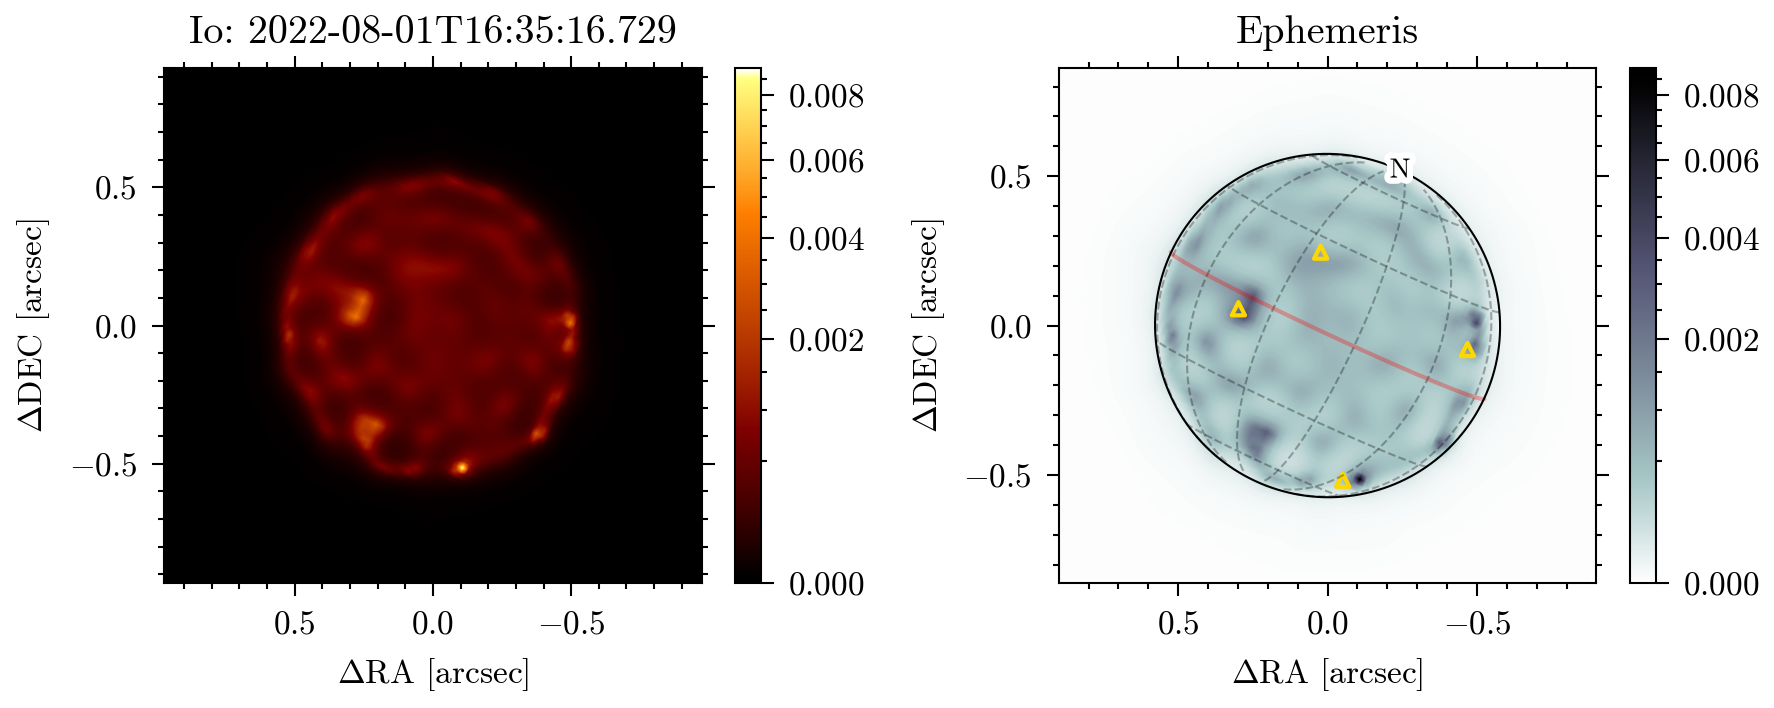

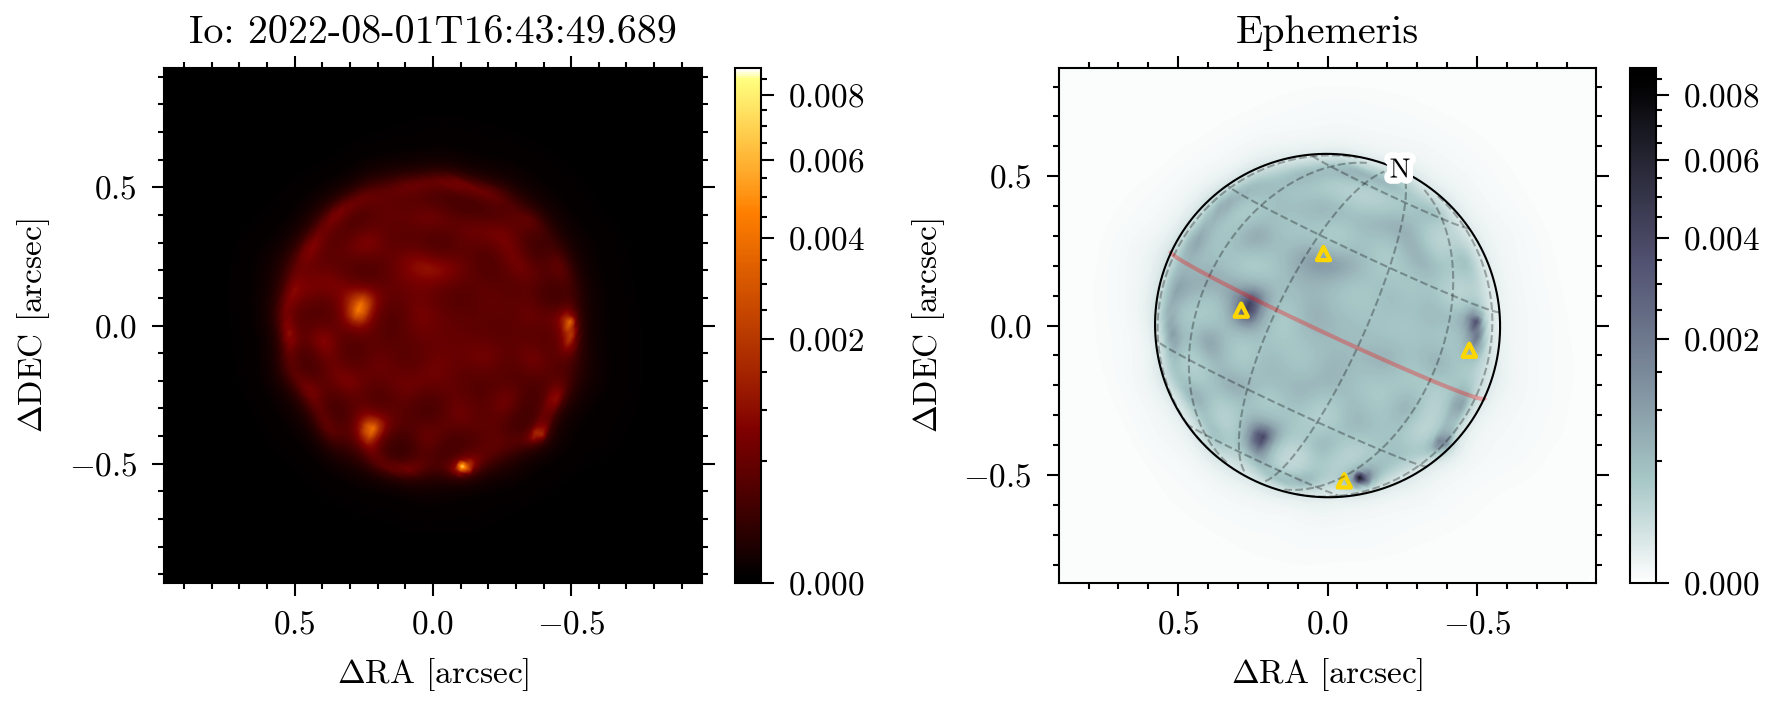

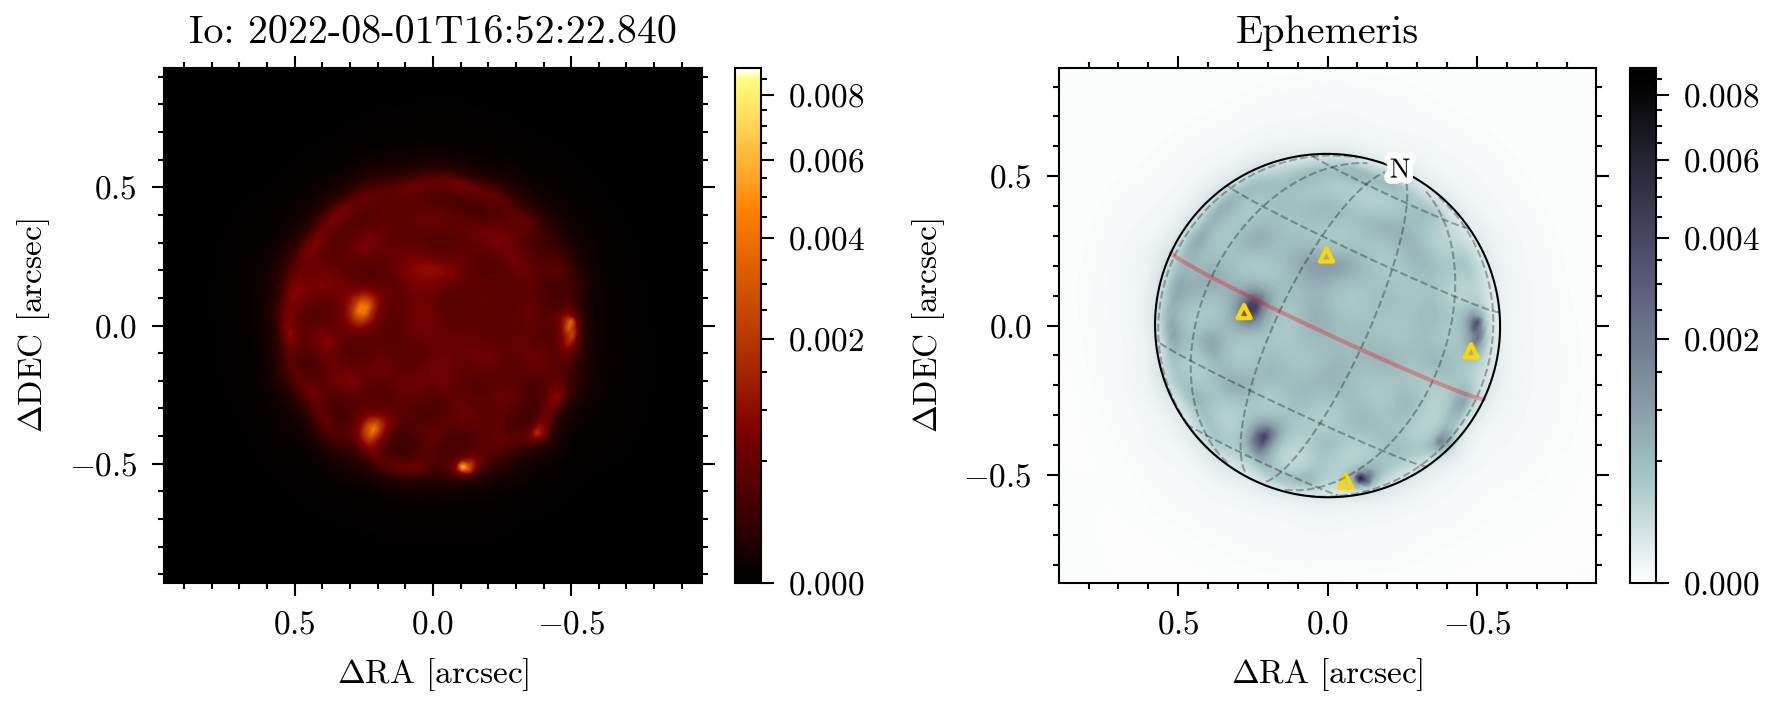

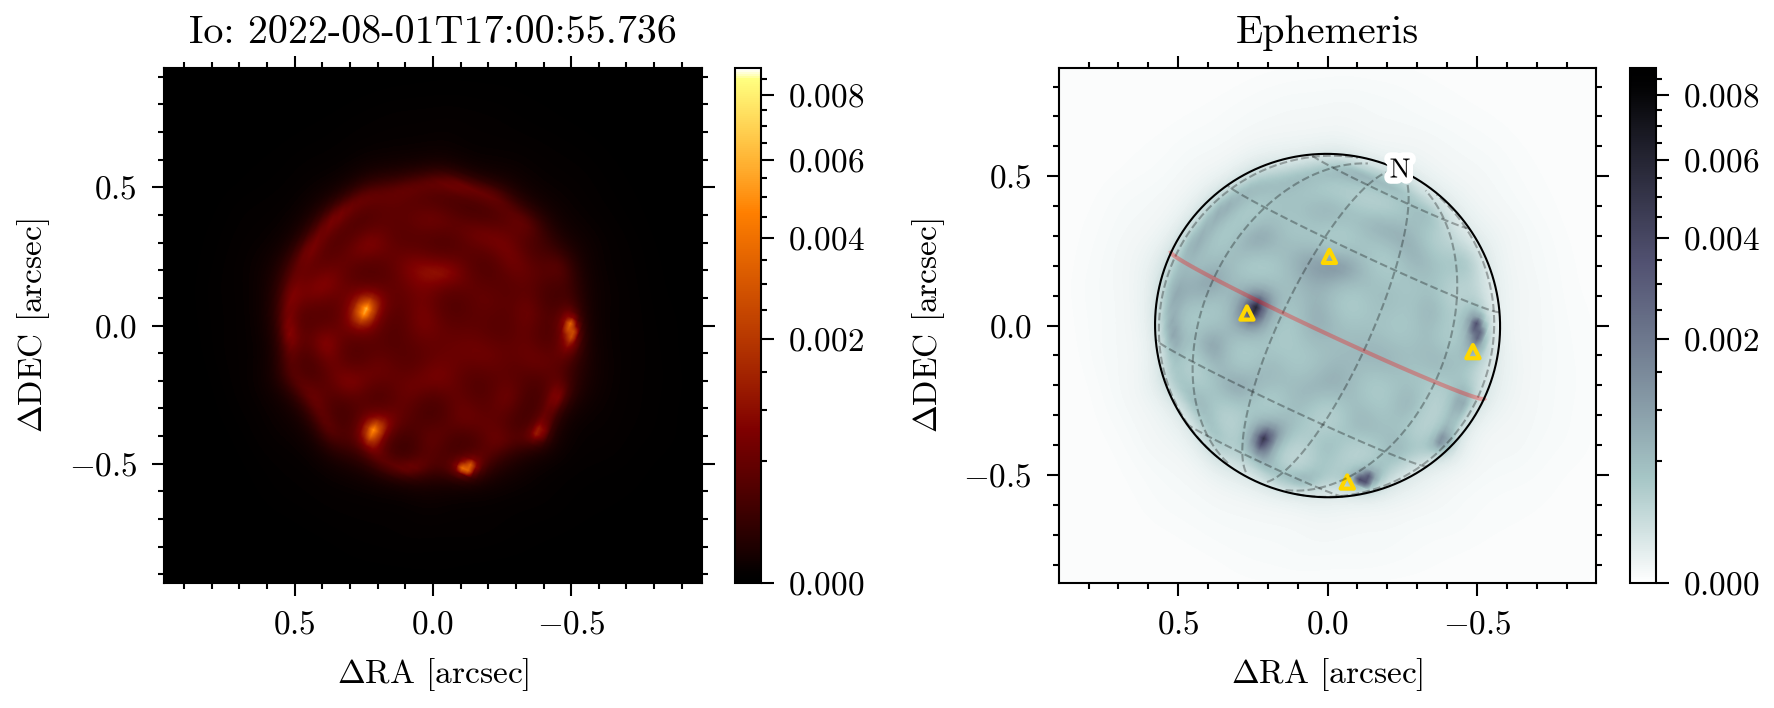

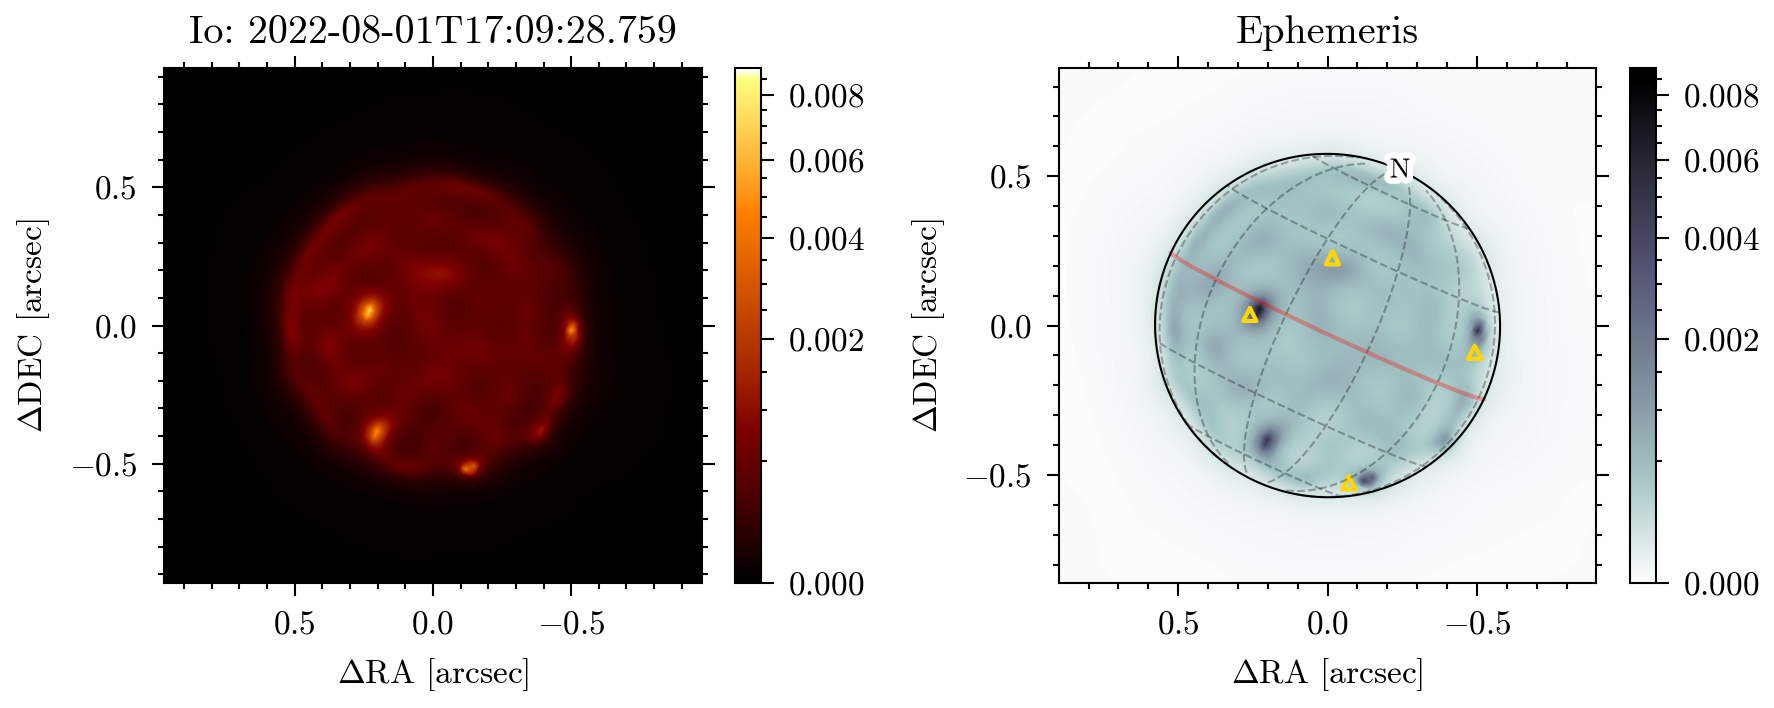

In [ ]:
# from planetmapper.kernel_downloader import download_urls

# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/")
# download_urls("https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/")
# download_urls(
#     "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/spk/satellites/jup365.bsp"
# )
# download_urls("https://naif.jpl.nasa.gov/pub/naif/JWST/kernels/spk/")

import astropy
import scipy
import numpy

io_peak_flux = np.array([result.model.get_distribution(exp) for exp in sci_fits]).max()
clip_value = 0.001

save_dir = "gifs/spinning_io/"
for exp, file in zip(sci_fits, sci_files):

    dist = result.model.get_distribution(exp)

    time = astropy.time.Time(file[0].header["EXPMID"], format="mjd").isot
    center = compute_com_physical(
        np.clip(dist, min=0, max=clip_value),
        model.psf_pixel_scale / model.oversample,
    )

    fig, ax = plt.subplots(1, 2, figsize=(6, 2.5))
    c0 = plot_result(
        ax[0],
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="afmhot_u",
        vmax=io_peak_flux,
        power=0.5,
        roll_angle_degrees=-rolls[exp.filename],
        translate=-center,
        scale=source_size / 75.0,
    )

    c1 = plot_io_with_ephemeris(
        ax[1],
        dist,
        pixel_scale=model.psf_pixel_scale / model.oversample,
        cmap="bone_ur",
        exp=exp,
        data_dir=uncal_path,
        vmax=io_peak_flux,
        points=list(features.values()),
        # contour=True,
        bg_color="white",
        power=0.5,
        translate=-center,
        roll_angle_degrees=-rolls[exp.filename],
        scale=source_size / 75.0,
    )

    fig.colorbar(c0)
    ax[0].set_title(f"Io: {time}")
    ax[1].set_title(f"Ephemeris")
    plt.tight_layout()
    fig.colorbar(c1, ax=ax[1])
    plt.savefig(output_path + f"{time}.png", dpi=300)
    # plt.close()
    plt.show()

In [ ]:
dorito.plotting.create_gif_from_dir(output_path, "io.gif", duration=300)

In [ ]:
io = np.load("files/io144.npy")

Observation('/media/morgana2/snert/max/data/JWST/IO/uncal/jw01373017001_04102_00001_nis_uncal.fits', target='IO', utc='2022-08-01T16:35:16.729000', observer='JAMES WEBB SPACE TELESCOPE')


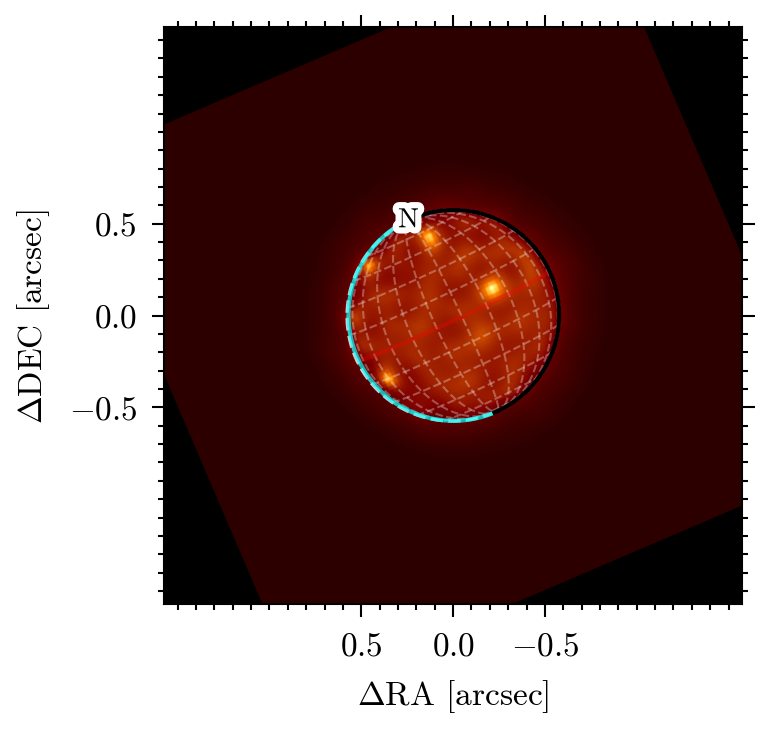

In [ ]:
import planetmapper


features = {
    "seth": (--131.67, -5.35),  # long [deg], lat [deg]
    # "P197": (None, None),
    "masubi": (--56.18, -49.6),
    "leizi": (--46.16, 14.25),
    # "amirani": (--114.68, 24.46),
    # "subobs": (--107.57361768, 2.60587485),
}

exp = sci_fits[0]
body = planetmapper.Observation(uncal_path + exp.filename[:-5] + "_nis_uncal.fits")
# if points is not None:
#     body.coordinates_of_interest_lonlat = points


def coordinate_func(ra, dec):
    x, y = body.radec2angular(ra, dec)
    return -x, y


fig, ax = plt.subplots(figsize=(3, 2.5))

print(body)

# body.plot_wireframe_custom(
body.plot_wireframe_angular(
    ax,
    # coordinate_func=coordinate_func,
    aspect_adjustable="box",
    add_title=False,
    label_poles=True,
    indicate_equator=True,
    indicate_prime_meridian=False,
    grid_interval=15,
    grid_lat_limit=75,
    formatting={
        "limb": {
            "linestyle": "--",
            "linewidth": 0.8,
            "alpha": 0.8,
            "color": "white",
        },
        "grid": {
            "linestyle": "--",
            "linewidth": 0.5,
            "alpha": 0.3,
            "color": "white",
        },
        "equator": {"linewidth": 1, "color": "r", "label": "equator"},
        "terminator": {
            "linewidth": 1,
            "linestyle": "-",
            "color": "aqua",
            "alpha": 0.7,
            "label": "terminator",
        },
        "coordinate_of_interest_lonlat": {
            "color": "g",
            "marker": "^",
            "s": 10,
            "label": "volcano",
        },
        # 'limb_illuminated': {'color': 'b'},
    },
)

dorito.plotting.plot_result(
    ax,
    io,
    rolls[exp.filename],
    pixel_scale=model.psf_pixel_scale / model.oversample,
)